In [23]:
from dataclasses import dataclass
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np 
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torchfuzzy import FuzzyLayer, DefuzzyLinearLayer, FuzzyBellLayer, DefuzzyMaxLayer
import piqa
import sklearn.metrics as metrics
from sklearn.manifold import TSNE
from torchvision.transforms import v2
from torchinfo import summary
from matplotlib.colors import ListedColormap


In [24]:
batch_size = 256
learning_rate_ae = 1e-4
num_epochs_ae = 100
latent_dim = 8
kernels = 8
fuzzy_rules_count = 32
mnist_class_anomaly = 4
prefix = f"fuzzy_snn"
writer = SummaryWriter(f'runs/mnist/{prefix}_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

binary_cmap = ListedColormap(['yellow', 'red'], N=2)
device

device(type='cuda')

## Датасет  

In [25]:
def norm_and_transform(x):
    nimg = x.view(-1, 28, 28)
    nimg = torch.clamp(nimg, 0, 1)
    return nimg

def clamp(x):
    #nimg = 2.0*(x.view(-1, 28, 28) - 0.5)
    nimg = torch.clamp(x, 0, 1)
    return nimg

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Lambda(norm_and_transform)
])

augmentation = transforms.Compose([
    transforms.RandomRotation(15, fill=0), 
    transforms.RandomAffine(degrees=5, translate=(0.1, 0.1), fill=0), 
    #transforms.RandomCrop(size=26),
    #transforms.Resize(size=(28, 28)),
    transforms.Lambda(clamp)
])

In [26]:
class DatasetWithRandomPairing(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self._dataset = dataset

    def __len__(self):
        return len(self._dataset)

    def __getitem__(self, idx):
        img_a, label_a = self._dataset[idx]
        expected = 0
        if np.random.random() < 0.5:
            expected = 1
        img_b, label_b = self._dataset[np.random.randint(0,len(self._dataset))]
        #while((expected == 0 and label_a == label_b) or (expected == 1 and label_a != label_b)):
        #    img_b, label_b = self._dataset[np.random.randint(0,len(self._dataset))]
        
        return (img_a, img_b, 0 if label_a == label_b else 1, label_a, label_b)
        

In [27]:
def get_target_and_mask(target_label):
    t = target_label
    return t 

train_data = DatasetWithRandomPairing(datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=True, 
    transform = transform,
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
))

idx = (train_data._dataset.targets != mnist_class_anomaly)
train_data._dataset.targets = train_data._dataset.targets[idx]
train_data._dataset.data = train_data._dataset.data[idx]
len(train_data)

54158

загружаем тестовую выборку

In [28]:
test_data = DatasetWithRandomPairing(datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=False, 
    transform=transform, 
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
))
len(test_data)

10000

Создаем итераторы датасетов

In [29]:

train_loader = torch.utils.data.DataLoader(
    train_data, 
    batch_size=batch_size, 
    shuffle=True,
    
)
test_loader = torch.utils.data.DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False,
)

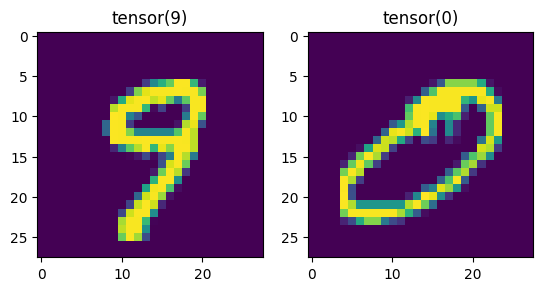

In [30]:
for img_a, img_b, lab, la, lb in iter(train_loader):
    R, C = 1, 2
    #plt.title(lab[0])
    plt.subplot(R, C, 1)
    plt.title(la[0])
    plt.imshow(img_a[0].squeeze())
    plt.subplot(R, C, 2)
    plt.title(lb[0])
    plt.imshow(img_b[0].squeeze())
    
    break

## Модель

In [31]:
class FSNN(nn.Module):

    def __init__(self, latent_dim, fuzzy_rules_count, kernels):
        super(FSNN, self).__init__()
                
        self.encoder = nn.Sequential(
            nn.Conv2d(1, kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(kernels, kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(kernels, 2*kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(2*kernels, 2*kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(2*kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(2*kernels, 4*kernels, kernel_size = 5, bias=False), 
            nn.Conv2d(4*kernels, 4*kernels, kernel_size = 5, bias=False), 
            nn.BatchNorm2d(4*kernels, affine=False), 
            nn.SiLU(),

            nn.Conv2d(4*kernels, 8*kernels, kernel_size = 4, bias=False), 
            nn.BatchNorm2d(8*kernels, affine=False), 
            nn.Flatten(),
            nn.Linear(8*kernels, latent_dim, bias=False)
        )

        initial_centroids = (0.5 - np.random.random((fuzzy_rules_count, latent_dim)))#np.zeros((fuzzy_rules_count, latent_dim))##0*
        initial_scales = 10 * np.ones((fuzzy_rules_count, latent_dim))
        self.fuzzy = FuzzyLayer.from_centers_and_scales(initial_centroids, initial_scales, trainable=True)

        
    def embedding(self, x):
        return self.encoder(x)
    
    def fuzzy_inference(self, dmu):
        return self.fuzzy(dmu)
    
    def forward(self, x):
        x = self.encoder(x)
        fz = self.fuzzy(x)
        return x, fz
    
    def set_freeze_fuzzy_except_centroids(self, is_freeze):
        self.fuzzy.scales.requires_grad = not is_freeze
        for r in self.fuzzy.rots:
            r.requires_grad = not is_freeze


#inp = torch.rand(10, 1, 28, 28)
#m = FSNN(latent_dim, fuzzy_rules_count, 16)
#summary(m, input_size=(batch_size, 1, 28, 28))


In [32]:
fvae = FSNN(latent_dim=latent_dim, fuzzy_rules_count=fuzzy_rules_count, kernels=kernels).to(device)

num_params = sum(p.numel() for p in fvae.parameters() if p.requires_grad)
print(f'Number of parameters: {num_params:,}')

summary(fvae, input_size=(batch_size, 1, 28, 28))

Number of parameters: 84,488


Layer (type:depth-idx)                   Output Shape              Param #
FSNN                                     [256, 8]                  --
├─Sequential: 1-1                        [256, 8]                  --
│    └─Conv2d: 2-1                       [256, 8, 24, 24]          200
│    └─Conv2d: 2-2                       [256, 8, 20, 20]          1,600
│    └─BatchNorm2d: 2-3                  [256, 8, 20, 20]          --
│    └─SiLU: 2-4                         [256, 8, 20, 20]          --
│    └─Conv2d: 2-5                       [256, 16, 16, 16]         3,200
│    └─Conv2d: 2-6                       [256, 16, 12, 12]         6,400
│    └─BatchNorm2d: 2-7                  [256, 16, 12, 12]         --
│    └─SiLU: 2-8                         [256, 16, 12, 12]         --
│    └─Conv2d: 2-9                       [256, 32, 8, 8]           12,800
│    └─Conv2d: 2-10                      [256, 32, 4, 4]           25,600
│    └─BatchNorm2d: 2-11                 [256, 32, 4, 4]           

## Losses

In [33]:
def criterion(x1, x2, label, margin: float = 1.0):
    """
    Computes Contrastive Loss
    the two samples are similar ((y = 0)) or dissimilar ((y = 1)).
    """

    dist = torch.nn.functional.pairwise_distance(x1, x2)

    loss = (1 - label) * torch.pow(dist, 2) \
        + (label) * torch.pow(torch.clamp(margin - dist, min=0.0), 2)
    loss = torch.mean(loss)

    return loss

In [34]:
def get_delta_loss(fz, labels):
    """
    the two samples are similar ((labels = 0)) or dissimilar ((labels = 1)).
    """
    return (fz.max(-1).values - 1 + labels).square().mean()

In [35]:
def get_loss(fz_a, fz_b, labels):
     """
    the two samples are similar ((labels = 0)) or dissimilar ((labels = 1)).
    """
     #acts = (fz_a * fz_b).sum(-1) #torch.cat((fz_a.unsqueeze(1), fz_b.unsqueeze(1)), dim=1).min(dim=1).values.squeeze(1).max(dim=1).values
     #reg = (1e-2 - fz_a.min(-1).values).clamp(min = 0) + (1e-2 - fz_b.min(-1).values).clamp(min = 0) 
     #sbj = (1 - fz_a.max(-1).values).square().sum() + (1 - fz_b.max(-1).values).square().sum()
     #norm = 0.5 * (1 - fz_a.sum(-1)).square().mean() + 0.5 * (1 - fz_b.sum(-1)).square().mean()
     #core = (1-fz_a[:,0]).square().mean() + (1-fz_b[:,0]).square().mean()
     obj = torch.minimum(fz_a, fz_b).max(-1).values#(fz_a*fz_b).max(-1).values#
     return torch.where(labels == 1, obj, 1 - obj).square().sum().log() #+ 1e-3 * norm #+ torch.where(labels == 0, 0, 1 - (fz_a*fz_b).sum()).square().sum()

#fz_a = torch.tensor([[1, 0], [0.8, 0.2], [0, 1]])
#fz_b = torch.tensor([[1, 0], [0.3, 0.7], [1, 0]])
#m = torch.tensor([[0.9]])
#labels = torch.tensor([1, 1, 0])


In [36]:
def centroid_loss(mu_a, mu_b, centroids, lambd = 1):
    sampled_x = torch.cat((mu_a, mu_b))
    distances = torch.cdist(sampled_x, centroids)
    neighs = torch.topk(distances, dim=-1, k=fuzzy_rules_count, largest=False).values
    weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
    return (weights*neighs).mean()

def centroid_loss_2(mu_a, mu_b, centroids, lambd = 1):
    sampled_x = torch.cat((mu_a, mu_b))
    distances = torch.cdist(centroids, sampled_x)
    neighs = torch.topk(distances, dim=-1, k = sampled_x.shape[0], largest=False).values
    weights = torch.exp(-torch.arange(0, sampled_x.shape[0])/lambd).repeat(fuzzy_rules_count,1).to(device)
    return (weights*neighs).sum(-1).mean()

def vanderwaals_loss(centroids, eps = 1, sigma = 1):
    distances = torch.cdist(centroids, centroids)
    distances = torch.triu(distances).flatten()
    distances = distances[distances.nonzero()].flatten() + sigma/2
    r = sigma / distances
    U = 4 * eps * (torch.pow(r,12) - torch.pow(r,6))
    return U.mean()

#centroids = fvae.fuzzy.get_centroids()
#mu_a = torch.rand(7, latent_dim).to(device)
#mu_b = torch.rand(7, latent_dim).to(device)

#sampled_x = torch.cat((mu_a, mu_b))
#distances = torch.cdist(sampled_x, centroids)
#neighs = torch.topk(distances, dim=-1, k=fuzzy_rules_count)
#lambd = 1
#weights = torch.exp(-torch.arange(0, fuzzy_rules_count)/lambd).repeat(sampled_x.shape[0],1).to(device)
#weights*neighs.values
# (torch.exp(-neighs.indices)*neighs.values).mean()
#deltas = sampled_x.unsqueeze(1).repeat(1, fuzzy_rules_count, 1) - centroids[neighs]
#exponent_part = torch.exp(-neighs/lambd).unsqueeze(2).repeat(1, 1, latent_dim)
#exponent_part*deltas



In [37]:
def keep_eigenvals_positive_loss(layer, eps = 1e-10):
    ev = layer.get_transformation_matrix_eigenvals().real.min()
    ev = torch.clamp(ev, max=eps)
    return -ev

def ev_loss(layer, min_vol = 5, max_vol = 15):
    ev = layer.get_transformation_matrix_eigenvals().real
    ev_min = ev.min(-1).values
    ev_max = ev.max(-1).values
    return (ev_min - min_vol).clamp(max = 0).square().sum() + (max_vol - ev_max).clamp(max = 0).square().sum()

In [38]:
def get_match_rates(fz_a, fz_b):
    acts = (fz_a*fz_b).sum(-1)#torch.cat((fz_a.unsqueeze(1), fz_b.unsqueeze(1)), dim=1).min(dim=1).values.squeeze(1).max(dim=1).values
    return acts.cpu().numpy()

In [39]:
def get_class_matching_matrix(confm):
    rmat = np.zeros((confm.shape[0], confm.shape[0]))
    winners = np.argmax(confm, axis=0)
    for i in range(confm.shape[1]):
        lm = winners[i]
        rmat[:, lm] += confm[:, i]
    return rmat


## Train AE

In [40]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']
    
def train(model, dataloader, optimizer, optimizer_ct, sched, prev_updates, epoch, writer=None):
    model.train()  
    model.set_freeze_fuzzy_except_centroids(True)
    for batch_idx, (img_a, img_b, labels, _, _) in enumerate(tqdm(dataloader, disable=True)):
        
        aimg_a = img_a.to(device)#augmentation(img_a).to(device)
        aimg_b = img_b.to(device)#augmentation(img_b).to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()  
        
        mu_a = model.embedding(aimg_a)  
        mu_b = model.embedding(aimg_b)  
        fz_a = model.fuzzy_inference(mu_a)
        fz_b = model.fuzzy_inference(mu_b)
        centroids = model.fuzzy.get_centroids()
        #loss = criterion(mu_a, mu_b, labels) + centroid_loss(mu_a, mu_b, centroids.detach(), 1)
        #ev_loss = keep_eigenvals_positive_loss(model.fuzzy)
        #if ev_loss.item() > 0:
        #    ev_loss.backward(retain_graph=True)
        #ev_loss(model.fuzzy).backward(retain_graph=True)
            
        centroid_loss_2(mu_a, mu_b, centroids, 1).backward(retain_graph=True)
        get_loss(fz_a, fz_b, labels).backward()
        
        #loss.backward()
        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1e-2)
        optimizer.step()  

        #centroid adjusting
        #optimizer_ct.zero_grad()
        #centroids = model.fuzzy.get_centroids()
        #centroid_loss(mu_a.detach(), mu_b.detach(), centroids, 1).backward()
        #optimizer_ct.step()
        
        if sched is not None:
            sched.step()
        
    if writer is not None:
        writer.add_scalar('FSNN/LR', get_lr(optimizer), global_step=epoch)
        #writer.add_scalar('FSNN/LR', get_lr(optimizer_ct), global_step=epoch)
        
        
    return prev_updates + len(dataloader)

In [41]:
def test(model, dataloader, cur_step, epoch, writer=None):
    model.eval() 

    test_loss = 0.0
    embedings = []
    labels_expected = []
    predicted_match = []
    predicted_label = []
    match_true = []
    match_pred = []
    confm = np.zeros((10, fuzzy_rules_count))

    with torch.no_grad():
        for img_a, img_b, labels, la, lb in tqdm(test_loader, desc='Test MNIST', disable=True):
            aimg_a = img_a.to(device)
            aimg_b = img_b.to(device)
            labels = labels.to(device)
            
            mu_a = model.embedding(aimg_a)  
            mu_b = model.embedding(aimg_b)  

            #centroids = model.fuzzy.get_centroids()
            fz_a = model.fuzzy_inference(mu_a)
            fz_b = model.fuzzy_inference(mu_b)
            test_loss += get_loss(fz_a, fz_b, labels) 

            #test_loss += get_loss(fz_a, fz_b, labels) #(fz_a*fz_b).sum(-1).square().mean().item()
            embedings.append(mu_a.cpu().numpy())
            fz_a_mx = fz_a.argmax(1)
            predicted_match.append(torch.where(fz_a.max(1).values > 0.1, fz_a_mx, -1).cpu().numpy())#
            predicted_label.append(la.cpu().numpy())#torch.where(fz_a.max(1).values>0.1, fz_a_mx, -1)
            labels_expected.append((la == mnist_class_anomaly).cpu().numpy())
            
            for i, j in zip(la.cpu().numpy(), fz_a_mx.cpu().numpy()):
                confm[i, j] += 1

            rates = torch.pairwise_distance(mu_a, mu_b).cpu().numpy()#fz.max(-1).values.cpu().numpy() #get_match_rates(fz_a, fz_b)
            for f, l in  zip(rates, labels):
                match_pred.append(f)        
                if l == 1:
                    match_true.append(1)
                else:
                    match_true.append(0)
            
    fpr, tpr, _ = metrics.roc_curve(match_true, match_pred)
    roc_auc = metrics.auc(fpr, tpr)

    embedings = np.concatenate(embedings, axis=0)
    predicted_label = np.concatenate(predicted_label, axis = 0)
    predicted_match = np.concatenate(predicted_match, axis = 0)
    labels_expected = np.concatenate(labels_expected, axis = 0)
    test_loss /= len(dataloader)
    
    print(f'[{cur_step}] Loss: {test_loss:.4f} AUC: {roc_auc:.4f}')
    
    if writer is not None:
        writer.add_scalar('FSNN/AUC', roc_auc, global_step=cur_step)
        writer.add_scalar('FSNN/Loss', test_loss, global_step=cur_step)
        
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        centroids = model.fuzzy.get_centroids().detach().cpu().numpy()
        ax[0].scatter(embedings[:, 0],      embedings[:,  1], c=predicted_label, cmap='tab10', s=2)
        ax[0].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[1].scatter(embedings[:, 0],      embedings[:,  1], c=predicted_match, cmap='tab10', s=2)
        ax[1].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        ax[2].scatter(embedings[:, 0],      embedings[:,  1], c=labels_expected, cmap=binary_cmap, s=2)
        ax[2].scatter(centroids[:, 0],      centroids[:, 1], marker='2', c='black', s= 50)
        
        writer.add_figure('FSNN/Emedding', fig, global_step=cur_step)

        fig, ax = plt.subplots(1, 1, figsize=(9, 9))
        
        ax.matshow(get_class_matching_matrix(confm))
        writer.add_figure('FSNN/ConfMatrix', fig, global_step=cur_step)



In [42]:
prev_updates = 0

In [43]:
optimizer_ae = torch.optim.Adam(fvae.parameters(), lr=learning_rate_ae)
optimizer_ct = torch.optim.Adam(fvae.fuzzy.parameters(), lr=learning_rate_ae)
#sched = torch.optim.lr_scheduler.OneCycleLR(optimizer_ae, learning_rate_ae, epochs=num_epochs_ae, steps_per_epoch=len(train_loader))
sched = torch.optim.lr_scheduler.ConstantLR(optimizer_ae, learning_rate_ae)
sched_ct = torch.optim.lr_scheduler.ConstantLR(optimizer_ct, learning_rate_ae/100)

In [44]:
for epoch in range(num_epochs_ae):    
    prev_updates = train(fvae, train_loader, optimizer_ae, optimizer_ct, sched, prev_updates, epoch, writer=writer)
    test(fvae, test_loader, prev_updates, epoch, writer=writer)
    #sched_ct.step()
    #scheduler.step()

[212] Loss: 3.1924 AUC: 0.5702
[424] Loss: 3.0841 AUC: 0.6010
[636] Loss: 3.0317 AUC: 0.6006
[848] Loss: 2.9842 AUC: 0.6096
[1060] Loss: 3.0545 AUC: 0.6280
[1272] Loss: 3.0350 AUC: 0.6658
[1484] Loss: 3.0029 AUC: 0.6783
[1696] Loss: 3.0511 AUC: 0.6912
[1908] Loss: 2.9749 AUC: 0.7146
[2120] Loss: 2.9567 AUC: 0.7218
[2332] Loss: 3.0592 AUC: 0.7611
[2544] Loss: 2.9474 AUC: 0.7676
[2756] Loss: 2.9985 AUC: 0.7825
[2968] Loss: 2.8685 AUC: 0.7896
[3180] Loss: 2.9827 AUC: 0.7900
[3392] Loss: 2.9885 AUC: 0.7963
[3604] Loss: 2.9133 AUC: 0.8072
[3816] Loss: 2.9281 AUC: 0.8021
[4028] Loss: 2.9334 AUC: 0.8129
[4240] Loss: 2.8900 AUC: 0.8393
[4452] Loss: 2.9589 AUC: 0.8222
[4664] Loss: 2.8390 AUC: 0.8134
[4876] Loss: 2.9527 AUC: 0.8383
[5088] Loss: 2.9024 AUC: 0.8300
[5300] Loss: 2.9547 AUC: 0.8543
[5512] Loss: 2.9136 AUC: 0.8564
[5724] Loss: 2.8499 AUC: 0.8273
[5936] Loss: 2.9199 AUC: 0.8324
[6148] Loss: 2.9432 AUC: 0.8105
[6360] Loss: 2.8037 AUC: 0.8122
[6572] Loss: 2.8123 AUC: 0.8242
[6784] Loss:

## Визуализируем результаты

In [45]:
fvae.eval()

FSNN(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (1): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (3): SiLU()
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (5): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (6): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (7): SiLU()
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (9): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
    (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (11): SiLU()
    (12): Conv2d(32, 64, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_fea

In [46]:
fvae.fuzzy.get_transformation_matrix()

tensor([[[10.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0838],
         [ 0.0000, 10.0000,  0.0000,  ...,  0.0000,  0.0000,  0.5834],
         [ 0.0000,  0.0000, 10.0000,  ...,  0.0000,  0.0000, -0.5133],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ..., 10.0000,  0.0000,  0.0789],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000, 10.0000,  0.0421],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  1.0000]],

        [[10.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0835],
         [ 0.0000, 10.0000,  0.0000,  ...,  0.0000,  0.0000,  0.5827],
         [ 0.0000,  0.0000, 10.0000,  ...,  0.0000,  0.0000, -0.5134],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ..., 10.0000,  0.0000,  0.0788],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000, 10.0000,  0.0427],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  1.0000]],

        [[10.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0840],
         [ 0.0000, 10.0000,  0.0000,  ...,  0

In [47]:
fvae.fuzzy.get_transformation_matrix_eigenvals().real

tensor([[10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],
        [10., 10., 10., 10., 10., 10., 10., 10.],


In [48]:
fvae.fuzzy.get_centroids()

tensor([[ 0.0084, -0.0583,  0.0513, -0.0489, -0.0219, -0.0356, -0.0079, -0.0042],
        [ 0.0084, -0.0583,  0.0513, -0.0489, -0.0219, -0.0356, -0.0079, -0.0043],
        [ 0.0084, -0.0583,  0.0513, -0.0489, -0.0218, -0.0356, -0.0079, -0.0043],
        [ 0.0084, -0.0583,  0.0514, -0.0489, -0.0219, -0.0355, -0.0079, -0.0043],
        [ 0.0080, -0.0656,  0.0515, -0.0533, -0.0284, -0.0392, -0.0087, -0.0063],
        [ 0.0085, -0.0579,  0.0516, -0.0490, -0.0221, -0.0356, -0.0079, -0.0045],
        [ 0.0084, -0.0582,  0.0514, -0.0489, -0.0219, -0.0355, -0.0079, -0.0044],
        [ 0.0083, -0.0583,  0.0513, -0.0489, -0.0219, -0.0356, -0.0079, -0.0043],
        [ 0.0084, -0.0582,  0.0513, -0.0490, -0.0218, -0.0356, -0.0079, -0.0043],
        [ 0.0082, -0.0609,  0.0533, -0.0501, -0.0233, -0.0338, -0.0102, -0.0029],
        [ 0.0084, -0.0583,  0.0513, -0.0489, -0.0219, -0.0356, -0.0079, -0.0043],
        [ 0.0084, -0.0582,  0.0513, -0.0489, -0.0219, -0.0356, -0.0079, -0.0043],
        [ 0.0083

In [49]:
def get_arate_val(inp):
    _, fz = fvae.forward(inp)  
    return fz.max(-1).values.cpu().numpy()

MNIST HIST:   0%|          | 0/40 [00:00<?, ?it/s]

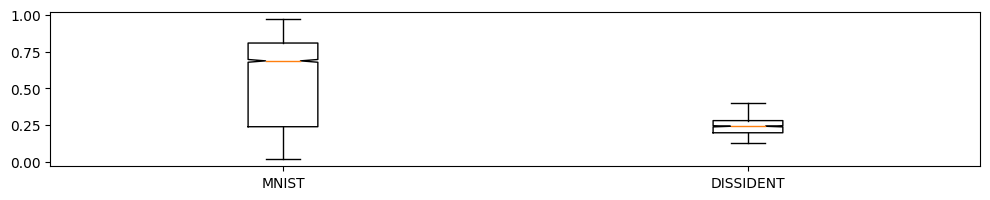

In [50]:
firings_mnist = {}
firings_mnist['MNIST'] = []
firings_mnist['DISSIDENT'] = []

with torch.no_grad():
    for data, _, _, target, _  in tqdm(test_loader, desc='MNIST HIST'):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        for f, l in  zip(rates, target):
            if l != mnist_class_anomaly:
                firings_mnist['MNIST'].append(f)
            else:
                firings_mnist['DISSIDENT'].append(f)
        

labels, data = firings_mnist.keys(), firings_mnist.values()

fig = plt.figure(figsize =(12, 2))
plt.boxplot(data, notch=True, showfliers=False)
plt.xticks(range(1, len(labels) + 1), labels)
plt.show()

writer.add_figure('Anomaly Detection', fig)

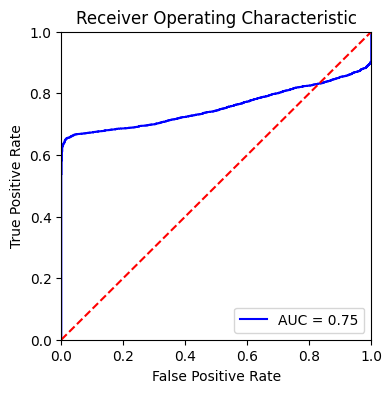

In [51]:
with torch.no_grad():
    firing_levels = []
    lab_true = []
    lab_pred = []

    for data, _, _, lab, _  in tqdm(test_loader, desc='Test MNIST', disable=True):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        
        for f, l in  zip(rates, lab):
            firing_levels.append(f)
            lab_pred.append(f)        
            if l == mnist_class_anomaly:
                lab_true.append(0)
            else:
                lab_true.append(1)
                    
    fpr, tpr, threshold = metrics.roc_curve(lab_true, lab_pred)
    roc_auc = metrics.auc(fpr, tpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = threshold[optimal_idx]
    fig = plt.figure(figsize =(4, 4))
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    writer.add_figure('ROC', fig)

EMNIST VIS:   0%|          | 0/40 [00:00<?, ?it/s]

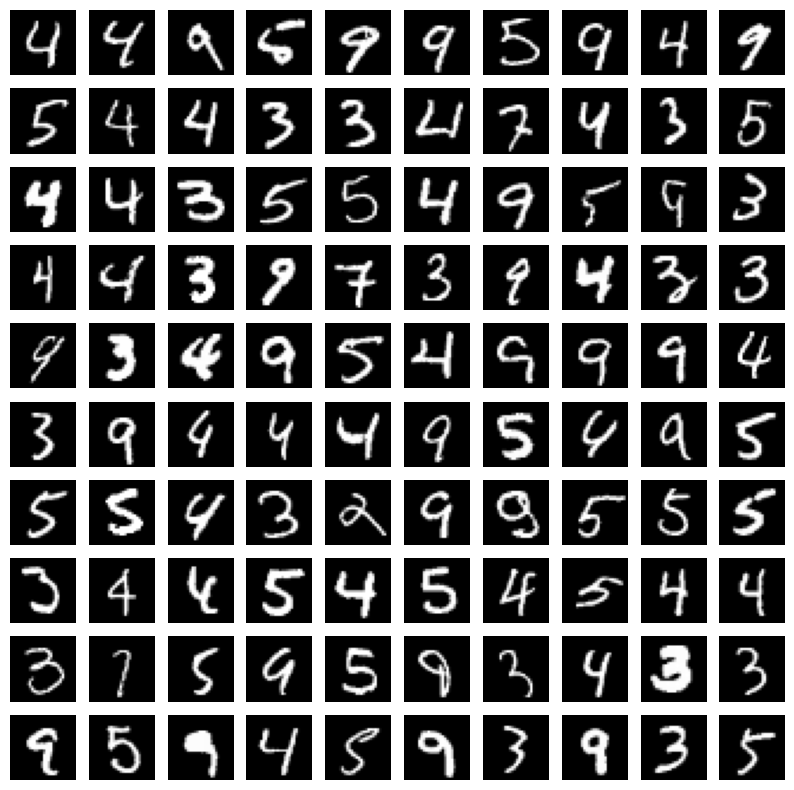

In [52]:
threshold = optimal_threshold
n = 0
fig, ax = plt.subplots(10, 10, figsize=(10, 10))
with torch.no_grad():
    for data, _, _, labels, _  in tqdm(test_loader, desc='EMNIST VIS'):
        if n >= 100:
            break
        data = data.view((-1, 1, 28, 28)).to(device) 
        
        arate = get_arate_val(data)
        
        for i in range(data.shape[0]):
            if(arate[i] < threshold):
                img = data[i]
                ax[int(n / 10), int(n % 10)].imshow(img.view(28, 28).cpu().detach().numpy(), cmap='gray')
                ax[int(n / 10), int(n % 10)].axis('off')
                n = n + 1
                    
                if n >= 100:
                    break